# IOI in GPT-2 small — full hidden-dimension attribution patching

## Thesis

**Attribution patching at the level of *every hidden coordinate* — and one level
*below* model components, at individual MLP neurons and at the dimensions inside
attention heads — is enough to (a) rediscover the IOI circuit of Wang et al.
(2022) from a single cheap forward+backward, (b) regenerate the paper's figures
from those numbers, and (c) reveal finer structure the component view hides:
specific MLP neurons, a sparse set of coordinates inside each head, and a few
heads beyond the published circuit.**

---

**Goal (Aruna's brief).** Instead of focusing on a hand-picked set of MLP
neurons / attention heads / the residual stream, look at **all hidden-dim
activations** so we can visualize the **whole network** for one task. Use
**attribution patching** to get the numbers cheaply, on **GPT-2 small** and the
**IOI** task. The challenge is *storing* the values. Then go past a replication:

1. Does the full-network view **recover** the IOI circuit?
2. **Trace** the paper's circuit (Fig 2) annotated with this new information.
3. **Regenerate the paper's figures** from our attribution (Figs 1, 2, 3b, 3c, 4b, 5b, 7, 8).
4. Go **one level below components** — to neurons in the MLPs and dimensions
   inside attention heads (Part E).
5. Does it capture any **other circuits** beyond the paper?

**Setup.** GPT-2 small, dataset [`mib-bench/ioi`](https://huggingface.co/datasets/mib-bench/ioi)
(Mechanistic Interpretability Benchmark, templated with counterfactuals), paper
*Interpretability in the Wild* (Wang et al. 2022, arXiv:2211.00593, in `paper/`).

**Method.** Denoising attribution patching, metric = `logit(IO) − logit(S)`:
`attr(a) = (a_clean − a_corrupt) · ∂metric_corrupt/∂a_corrupt`, evaluated for
*every* hidden unit from one clean forward + one corrupt forward + one backward.
For the intermediate-node figures (4b/5b) we use **edge attribution patching**.

> Note on nnsight: the brief suggested nnsight. nnsight reads activations fine,
> but its 0.7.0 gradient API (`with metric.backward(): x.grad`) raises
> `MissedProviderError` on GPT-2, so the engine below captures gradients with
> native PyTorch hooks on the same model. The attribution math is identical.

In [1]:
import os, json, math
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch, FancyBboxPatch, FancyArrowPatch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from huggingface_hub import hf_hub_download
from collections import defaultdict

torch.set_grad_enabled(True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FIGS = "figures"; os.makedirs(FIGS, exist_ok=True)
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

model = GPT2LMHeadModel.from_pretrained("openai-community/gpt2").to(DEVICE).eval()
tok = GPT2TokenizerFast.from_pretrained("openai-community/gpt2")
N_LAYER, N_HEAD = model.config.n_layer, model.config.n_head
D_MODEL = model.config.n_embd; D_HEAD = D_MODEL // N_HEAD
print(f"GPT-2 small: {N_LAYER} layers x {N_HEAD} heads, d_model={D_MODEL}")

# scale (good GPU): main runs use N_MAIN examples; per-counterfactual uses N_CF
N_MAIN, BS = 1000, 50
N_CF = 512


device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 small: 12 layers x 12 heads, d_model=768


## 1. Data — MIB IOI, clean/corrupt pairs, and the key token positions

In [2]:
POS_NAMES = ["IO", "S1", "S1+1", "S2", "END"]

def load_raw(split="test"):
    p = hf_hub_download("mib-bench/ioi", f"{split}.json", repo_type="dataset")
    return json.load(open(p, encoding="utf-8"))

def first_token(name):
    ids = tok(" " + name.strip())["input_ids"]
    return ids[0] if len(ids) == 1 else None

def find_positions(ids, io_id, s_id):
    s = [i for i, t in enumerate(ids) if t == s_id]
    io = [i for i, t in enumerate(ids) if t == io_id]
    if len(s) < 2 or len(io) < 1:
        return None
    return {"IO": io[0], "S1": s[0], "S1+1": s[0] + 1, "S2": s[-1], "END": len(ids) - 1}

class Batch:
    def __init__(self, clean, corrupt, io, s, L, pos):
        self.clean_ids, self.corrupt_ids = clean, corrupt
        self.io_ids, self.s_ids, self.seq_len, self.positions = io, s, L, pos

def build_batches(raw, n=N_MAIN, bs=BS, corruption="abc_counterfactual"):
    by_len = defaultdict(list); kept = 0
    for ex in raw:
        if kept >= n: break
        io_id, s_id = first_token(ex["choices"][0]), first_token(ex["choices"][1])
        if io_id is None or s_id is None: continue
        ci = tok(ex["prompt"])["input_ids"]
        ki = tok(ex[corruption]["prompt"])["input_ids"]
        if len(ci) != len(ki): continue
        pos = find_positions(ci, io_id, s_id)
        if pos is None: continue
        by_len[len(ci)].append((ci, ki, io_id, s_id, pos)); kept += 1
    batches = []
    for L, rows in by_len.items():
        for i in range(0, len(rows), bs):
            ch = rows[i:i+bs]
            P = {nm: torch.tensor([r[4][nm] for r in ch], device=DEVICE) for nm in POS_NAMES}
            batches.append(Batch(
                torch.tensor([r[0] for r in ch], device=DEVICE),
                torch.tensor([r[1] for r in ch], device=DEVICE),
                torch.tensor([r[2] for r in ch], device=DEVICE),
                torch.tensor([r[3] for r in ch], device=DEVICE), L, P))
    return batches

raw = load_raw("test")
ex = raw[0]
print("CLEAN  :", ex["prompt"])
print("CORRUPT:", ex["abc_counterfactual"]["prompt"], "  (ABC: repeated subject -> 3rd name)")
print("choices [IO,S] =", ex["choices"], "-> answer:", ex["choices"][ex["answerKey"]])
batches = build_batches(raw, n=N_MAIN, bs=BS, corruption="abc_counterfactual")
NUSED = sum(b.clean_ids.shape[0] for b in batches)
print(f"built {len(batches)} batches, {NUSED} usable examples, lengths {sorted({b.seq_len for b in batches})}")


CLEAN  : Then, Henry and Phil had a lot of fun at the harbor. Henry gave a basket to
CORRUPT: Then, Henry and Phil had a lot of fun at the harbor. Angel gave a basket to   (ABC: repeated subject -> 3rd name)
choices [IO,S] = ['Phil', 'Henry'] -> answer: Phil


built 27 batches, 1000 usable examples, lengths [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


## 2. The metric and a sanity check (paper Fig 1)

clean logit diff (IO-S) = +3.394   (paper reports 3.56)
corrupt (abc) logit diff = -0.363


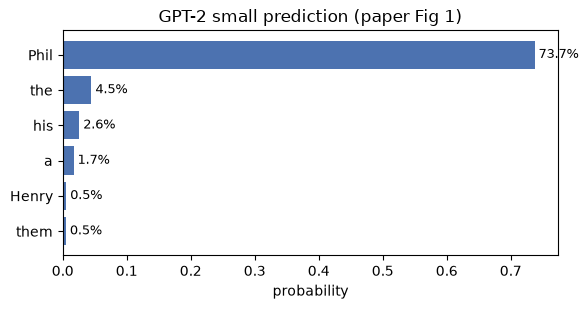

In [3]:
def logit_diff(logits, io_ids, s_ids):
    last = logits[:, -1, :]; idx = torch.arange(last.shape[0], device=last.device)
    return (last[idx, io_ids] - last[idx, s_ids]).mean()

# overall clean vs corrupt logit diff
cl, co, ntot = 0.0, 0.0, 0
with torch.no_grad():
    for b in batches:
        cl += float(logit_diff(model(b.clean_ids).logits, b.io_ids, b.s_ids)) * b.clean_ids.shape[0]
        co += float(logit_diff(model(b.corrupt_ids).logits, b.io_ids, b.s_ids)) * b.clean_ids.shape[0]
        ntot += b.clean_ids.shape[0]
CLEAN_LD = cl / ntot; CORRUPT_LD = co / ntot
print(f"clean logit diff (IO-S) = {CLEAN_LD:+.3f}   (paper reports 3.56)")
print(f"corrupt (abc) logit diff = {CORRUPT_LD:+.3f}")

# Fig 1: GPT-2's next-token prediction on an IOI prompt
ids = tok(ex["prompt"], return_tensors="pt").input_ids.to(DEVICE)
with torch.no_grad():
    probs = torch.softmax(model(ids).logits[0, -1], -1)
t = torch.topk(probs, 6)
labels = [tok.decode([i]).strip() for i in t.indices.tolist()]; vals = t.values.tolist()
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(range(6)[::-1], vals, color="#4c72b0")
ax.set_yticks(range(6)[::-1]); ax.set_yticklabels(labels)
for i, v in enumerate(vals): ax.text(v, 5 - i, f" {v*100:.1f}%", va="center", fontsize=9)
ax.set_xlabel("probability"); ax.set_title("GPT-2 small prediction (paper Fig 1)")
plt.tight_layout(); plt.savefig(f"{FIGS}/fig1_prediction.png", dpi=140); plt.show()


## 3. The canonical IOI circuit (ground truth from the paper)

26 heads in 7 classes, with the token position each class acts on. We use this
to overlay our maps, check coverage, and find *extra* heads.

In [4]:
CIRCUIT = {
    "name_mover":          [(9,9),(9,6),(10,0)],
    "negative_name_mover": [(10,7),(11,10)],
    "backup_name_mover":   [(9,0),(9,7),(10,1),(10,2),(10,6),(10,10),(11,2),(11,9)],
    "s_inhibition":        [(7,3),(7,9),(8,6),(8,10)],
    "induction":           [(5,5),(6,9),(5,8),(5,9)],
    "duplicate_token":     [(0,1),(3,0),(0,10)],
    "previous_token":      [(2,2),(4,11)],
}
CLASS_POSITION = {"name_mover":"END","negative_name_mover":"END","backup_name_mover":"END",
                  "s_inhibition":"END","induction":"S2","duplicate_token":"S2","previous_token":"S1+1"}
CLASS_COLOR = {"name_mover":"#2ca02c","negative_name_mover":"#d62728","backup_name_mover":"#98df8a",
               "s_inhibition":"#9467bd","induction":"#ff7f0e","duplicate_token":"#e377c2","previous_token":"#8c564b"}
H2C = {h:c for c,hs in CIRCUIT.items() for h in hs}
CIRCUIT_HEADS = set(H2C)
print(len(CIRCUIT_HEADS), "circuit heads in", len(CIRCUIT), "classes")


26 circuit heads in 7 classes


## Part A — All hidden dimensions (the full network)

We tile the whole forward pass: per layer we capture `resid_pre`, `attn_out`,
the 3072-wide `mlp_hidden`, `mlp_out`, `resid_post` — **73,728 hidden dims per
token position**. The *full* attribution tensor would be
`[examples × sites × seq × dim]` (~GBs); we never store it — we **reduce as we
stream**, accumulating per-dim and scalar summaries, so memory is
`O(sites × seq × dim)` regardless of #examples (the storage answer).

In [5]:
COMPONENTS = ["resid_pre","attn_out","mlp_hidden","mlp_out","resid_post"]
def site(l,c): return f"L{l:02d}.{c}"

def comp_hooks(model):
    acts, grads = {}, {}
    def grab(name):
        def h(_m,_i,out):
            t = out[0] if isinstance(out, tuple) else out
            acts[name] = t.detach()
            if t.requires_grad: t.register_hook(lambda g,n=name: grads.__setitem__(n,g.detach()))
        return h
    def grab_pre(name):
        def h(_m, inp):
            t = inp[0] if isinstance(inp, tuple) else inp
            acts[name] = t.detach()
            if t.requires_grad: t.register_hook(lambda g,n=name: grads.__setitem__(n,g.detach()))
        return h
    H=[]
    for i,blk in enumerate(model.transformer.h):
        H += [blk.register_forward_pre_hook(grab_pre(site(i,"resid_pre"))),
              blk.attn.register_forward_hook(grab(site(i,"attn_out"))),
              blk.mlp.act.register_forward_hook(grab(site(i,"mlp_hidden"))),
              blk.mlp.register_forward_hook(grab(site(i,"mlp_out"))),
              blk.register_forward_hook(grab(site(i,"resid_post")))]
    return H, acts, grads

def run_component(batches):
    scalar_signed, per_dim = defaultdict(float), {}
    n = 0
    for b in batches:
        H, acts, grads = comp_hooks(model)
        try:
            acts.clear(); grads.clear()
            ld = logit_diff(model(b.corrupt_ids).logits, b.io_ids, b.s_ids)
            model.zero_grad(set_to_none=True); ld.backward()
            c_acts = {k:v.clone() for k,v in acts.items()}; c_grads={k:v.clone() for k,v in grads.items()}
        finally:
            for h in H: h.remove()
        H, acts, grads = comp_hooks(model)
        try:
            acts.clear()
            with torch.no_grad(): model(b.clean_ids)
            cl_acts = {k:v.clone() for k,v in acts.items()}
        finally:
            for h in H: h.remove()
        for s in c_grads:
            attr = (cl_acts[s]-c_acts[s])*c_grads[s]        # [b,seq,dim]
            scalar_signed[s] += attr.sum().item()
            d = attr.sum(dim=(0,1)).cpu()
            per_dim[s] = per_dim.get(s, torch.zeros_like(d)) + d
        n += b.clean_ids.shape[0]
    inv = 1.0/n
    return {k:v*inv for k,v in scalar_signed.items()}, {k:v*inv for k,v in per_dim.items()}

comp_scalar, comp_perdim = run_component(batches)
n_dims = sum(v.numel() for v in comp_perdim.values())
print(f"tracked {n_dims:,} hidden dims; stored summaries only "
      f"(full tensor would be ~{NUSED*n_dims*20*4/1e9:.1f} GB at seq~20).")


tracked 73,728 hidden dims; stored summaries only (full tensor would be ~5.9 GB at seq~20).


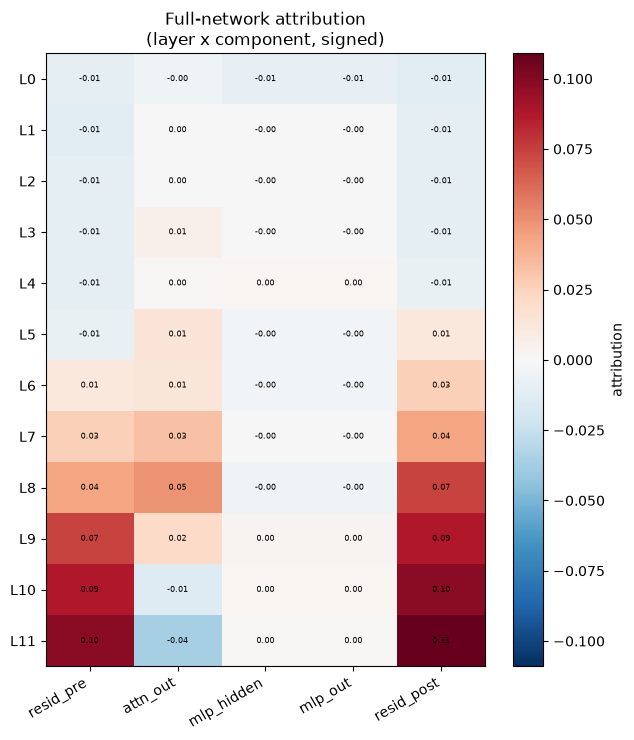

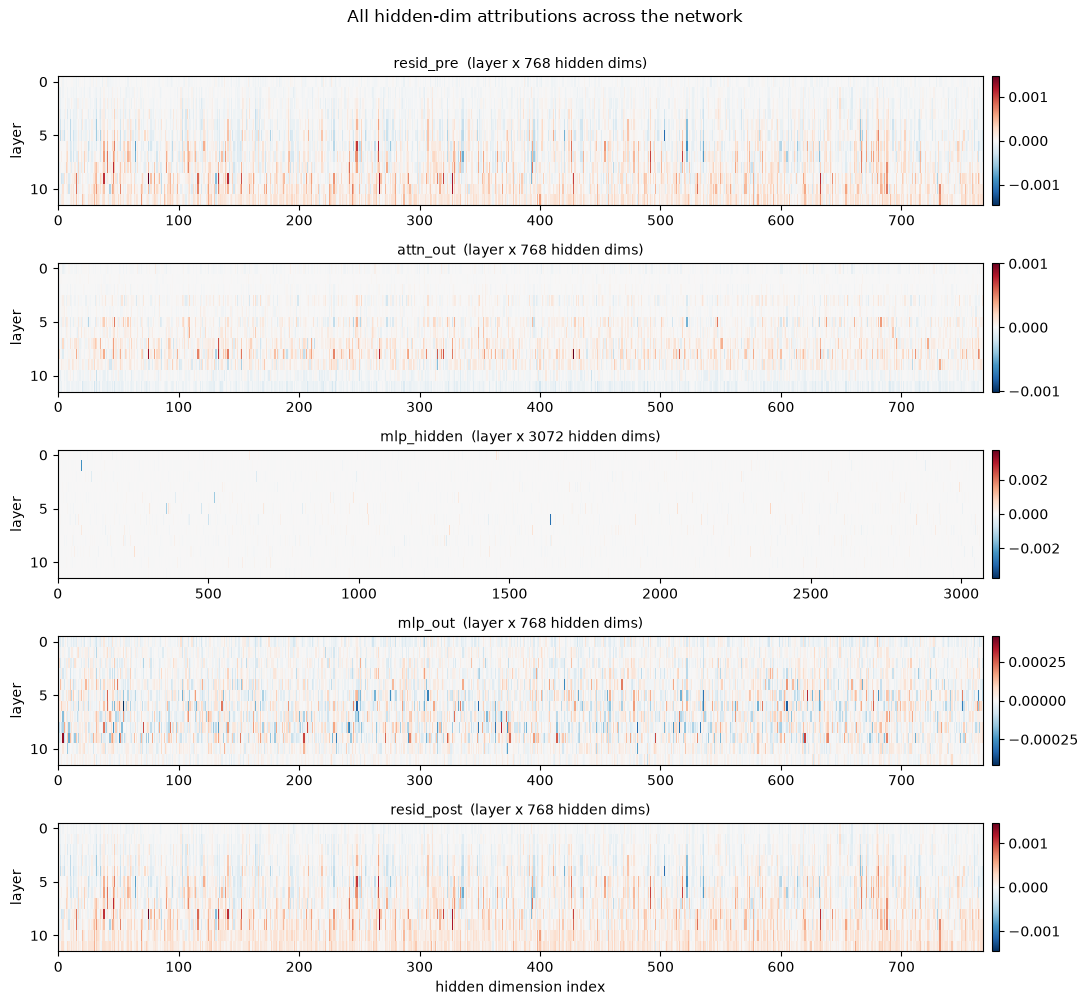

In [6]:
# (A1) full-network map: layer x component
mat = np.array([[comp_scalar.get(site(l,c),0.0) for c in COMPONENTS] for l in range(N_LAYER)])
v = np.abs(mat).max()
fig, ax = plt.subplots(figsize=(6.5,7.5))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
ax.set_xticks(range(len(COMPONENTS))); ax.set_xticklabels(COMPONENTS, rotation=30, ha="right")
ax.set_yticks(range(N_LAYER)); ax.set_yticklabels([f"L{i}" for i in range(N_LAYER)])
ax.set_title("Full-network attribution\n(layer x component, signed)")
for i in range(N_LAYER):
    for j in range(len(COMPONENTS)): ax.text(j,i,f"{mat[i,j]:.2f}",ha="center",va="center",fontsize=6)
fig.colorbar(im, ax=ax, label="attribution")
plt.tight_layout(); plt.savefig(f"{FIGS}/A_network_map.png", dpi=140); plt.show()

# (A2) every hidden dimension, per component
fig, axes = plt.subplots(len(COMPONENTS),1, figsize=(11, 2.0*len(COMPONENTS)))
for ax,c in zip(axes, COMPONENTS):
    dim = comp_perdim[site(0,c)].numel()
    M = np.array([comp_perdim[site(l,c)].numpy() for l in range(N_LAYER)])
    vv=np.abs(M).max() or 1
    im=ax.imshow(M, cmap="RdBu_r", vmin=-vv, vmax=vv, aspect="auto", interpolation="nearest")
    ax.set_title(f"{c}  (layer x {dim} hidden dims)", fontsize=10); ax.set_ylabel("layer")
    fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
axes[-1].set_xlabel("hidden dimension index")
fig.suptitle("All hidden-dim attributions across the network", y=1.001)
plt.tight_layout(); plt.savefig(f"{FIGS}/A_all_hidden_dims.png", dpi=140); plt.show()


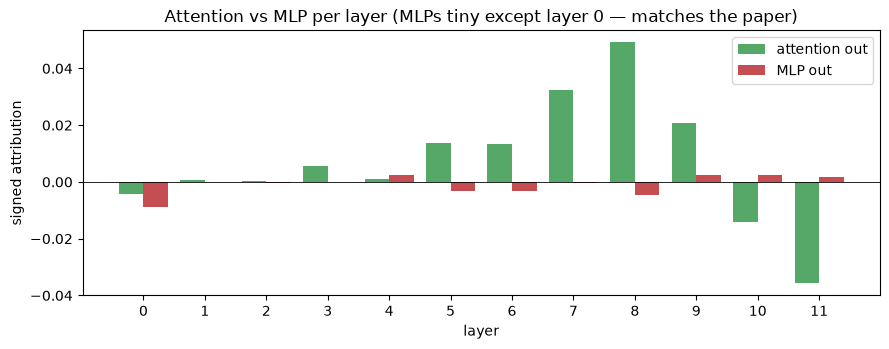

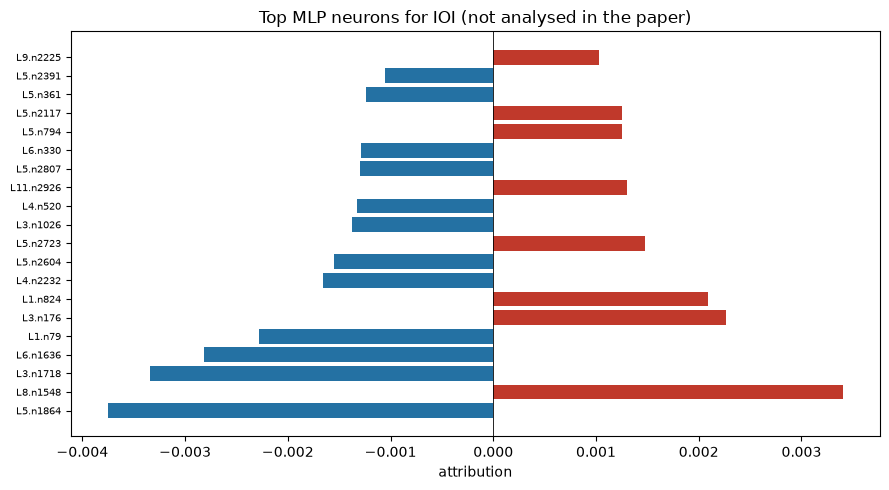

top MLP neurons: [('L5.n1864', -0.0038), ('L8.n1548', 0.0034), ('L3.n1718', -0.0033), ('L6.n1636', -0.0028), ('L1.n79', -0.0023), ('L3.n176', 0.0023), ('L1.n824', 0.0021), ('L4.n2232', -0.0017)]


In [7]:
# (A3) attention vs MLP per layer + (A4) top MLP neurons (paper does NOT analyse MLPs)
attn = [comp_scalar.get(site(l,"attn_out"),0.0) for l in range(N_LAYER)]
mlp  = [comp_scalar.get(site(l,"mlp_out"),0.0)  for l in range(N_LAYER)]
fig, ax = plt.subplots(figsize=(9,3.6))
ax.bar([i-0.2 for i in range(N_LAYER)], attn, 0.4, label="attention out", color="#55a868")
ax.bar([i+0.2 for i in range(N_LAYER)], mlp, 0.4, label="MLP out", color="#c44e52")
ax.axhline(0,color="k",lw=.6); ax.set_xticks(range(N_LAYER)); ax.set_xlabel("layer")
ax.set_ylabel("signed attribution"); ax.legend()
ax.set_title("Attention vs MLP per layer (MLPs tiny except layer 0 — matches the paper)")
plt.tight_layout(); plt.savefig(f"{FIGS}/A_attn_vs_mlp.png", dpi=140); plt.show()

rows=[]
for l in range(N_LAYER):
    vec = comp_perdim[site(l,"mlp_hidden")].numpy()
    for nrn in range(vec.size): rows.append((abs(vec[nrn]), float(vec[nrn]), l, nrn))
rows.sort(reverse=True); TOPMLP = rows[:20]
fig, ax = plt.subplots(figsize=(9,5))
lbl=[f"L{l}.n{nr}" for _,_,l,nr in TOPMLP]; val=[v for _,v,_,_ in TOPMLP]
ax.barh(range(20)[::-1], val[::-1], color=["#c0392b" if v>0 else "#2471a3" for v in val][::-1])
ax.set_yticks(range(20)[::-1]); ax.set_yticklabels(lbl[::-1], fontsize=7); ax.axvline(0,color="k",lw=.6)
ax.set_xlabel("attribution"); ax.set_title("Top MLP neurons for IOI (not analysed in the paper)")
plt.tight_layout(); plt.savefig(f"{FIGS}/D_top_mlp_neurons.png", dpi=140); plt.show()
print("top MLP neurons:", [(f"L{l}.n{nr}", round(v,4)) for _,v,l,nr in TOPMLP[:8]])


## Part B — Head-level circuit (per head, per position)

To trace the paper's head-level circuit we attribute per attention head (the
`c_proj` input `z`, reshaped into 12 heads) and per token position.

In [8]:
def run_heads(batches):
    total = torch.zeros(N_LAYER, N_HEAD)
    bypos = torch.zeros(N_LAYER, N_HEAD, len(POS_NAMES))
    n=0; cl=co=0.0; nb=0
    for b in batches:
        acts, grads = {}, {}; H=[]
        def mk(l):
            def h(_m,a):
                acts[l]=a[0]
                if a[0].requires_grad: a[0].register_hook(lambda g,l=l: grads.__setitem__(l,g.detach()))
            return h
        for l in range(N_LAYER):
            H.append(model.transformer.h[l].attn.c_proj.register_forward_pre_hook(mk(l)))
        try:
            acts.clear(); grads.clear()
            ld = logit_diff(model(b.corrupt_ids).logits, b.io_ids, b.s_ids)
            model.zero_grad(set_to_none=True); ld.backward()
            zc={l:acts[l].detach().clone() for l in acts}; zg={l:grads[l].clone() for l in grads}
            co += float(ld)
        finally:
            for h in H: h.remove()
        acts2={}; H=[]
        def mk2(l):
            def h(_m,a): acts2[l]=a[0].detach()
            return h
        for l in range(N_LAYER):
            H.append(model.transformer.h[l].attn.c_proj.register_forward_pre_hook(mk2(l)))
        try:
            with torch.no_grad(): clld = logit_diff(model(b.clean_ids).logits, b.io_ids, b.s_ids)
            zcl={l:acts2[l].clone() for l in acts2}; cl += float(clld)
        finally:
            for h in H: h.remove()
        bsz=b.clean_ids.shape[0]; nb+=1
        for l in zg:
            delta=(zcl[l]-zc[l]).reshape(bsz,-1,N_HEAD,D_HEAD)
            grad=zg[l].reshape(bsz,-1,N_HEAD,D_HEAD)
            attr=(delta*grad).sum(-1)            # [b,seq,nh]
            total[l]+=attr.sum(dim=(0,1)).cpu()
            for pi,pn in enumerate(POS_NAMES):
                idx=b.positions[pn]
                bypos[l,:,pi]+=attr[torch.arange(bsz,device=DEVICE),idx].sum(0).cpu()
        n+=bsz
    return total/n, bypos/n, cl/nb, co/nb

head_total, head_bypos, hcl, hco = run_heads(batches)
print(f"head attribution: clean={hcl:+.3f} corrupt={hco:+.3f}")

# coverage
flat=sorted(((abs(head_total[l,h].item()),head_total[l,h].item(),l,h)
             for l in range(N_LAYER) for h in range(N_HEAD)), reverse=True)
rank={(l,h):i for i,(_,_,l,h) in enumerate(flat)}
recovered=[f"{l}.{h}" for (l,h) in CIRCUIT_HEADS if rank[(l,h)]<26]
missed=[f"{l}.{h}" for (l,h) in CIRCUIT_HEADS if rank[(l,h)]>=26]
extras=[f"{l}.{h}" for _,_,l,h in flat[:26] if (l,h) not in CIRCUIT_HEADS]
print(f"circuit recovery: {len(recovered)}/26 circuit heads in top-26")
print("missed (dormant/weak):", missed)
print("extra non-circuit heads in top-26:", extras)


C:\Users\Valmi\AppData\Local\Temp\ipykernel_18904\683171149.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  co += float(ld)


head attribution: clean=+3.497 corrupt=-0.385
circuit recovery: 19/26 circuit heads in top-26
missed (dormant/weak): ['0.1', '0.10', '2.2', '9.0', '11.9', '4.11', '10.2']
extra non-circuit heads in top-26: ['9.4', '6.0', '4.3', '9.3', '11.6', '8.3', '6.6']


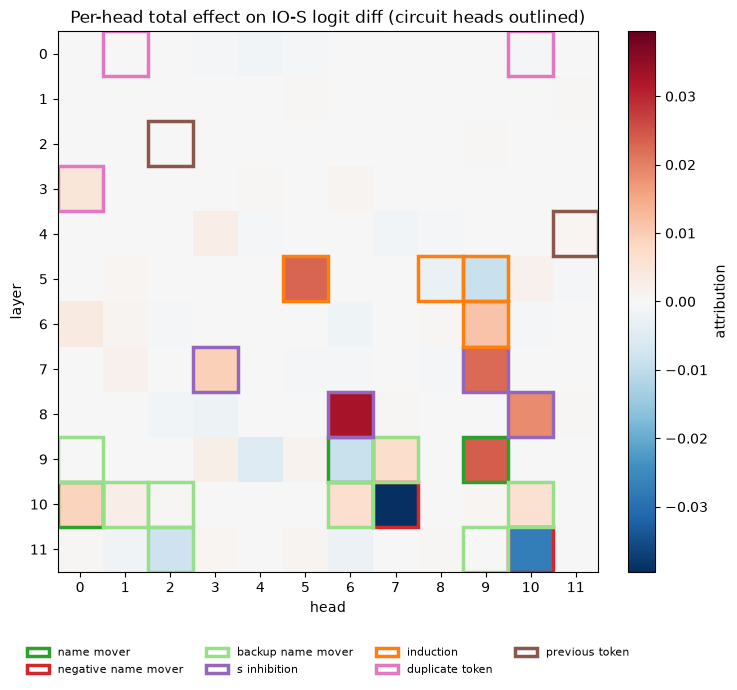

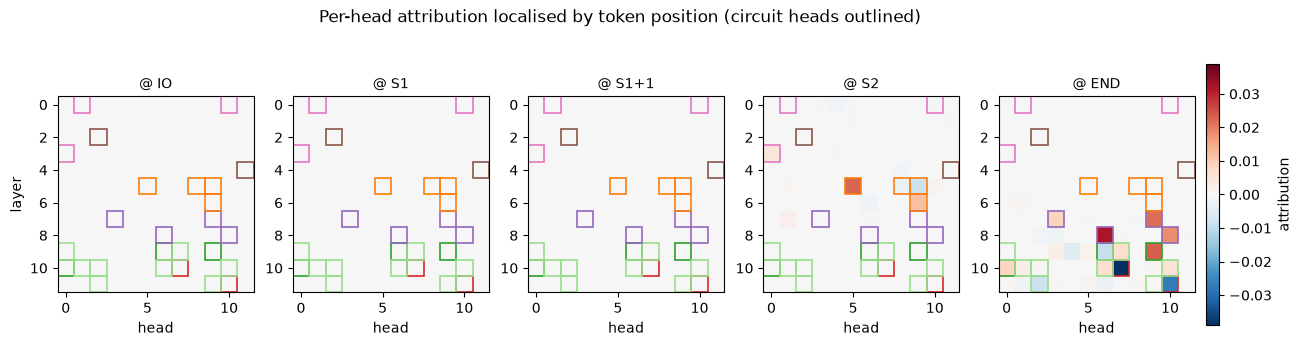

In [9]:
# (B1) 12x12 head total effect with circuit overlay  (our addition)
def head_overlay(mat, fname, title, cbar="attribution"):
    v=np.abs(mat).max() or 1
    fig,ax=plt.subplots(figsize=(8.5,7))
    im=ax.imshow(mat, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_xticks(range(N_HEAD)); ax.set_yticks(range(N_LAYER))
    ax.set_xlabel("head"); ax.set_ylabel("layer"); ax.set_title(title)
    for (l,h),c in H2C.items():
        ax.add_patch(Rectangle((h-.5,l-.5),1,1,fill=False,edgecolor=CLASS_COLOR[c],lw=2.5))
    handles=[Patch(edgecolor=CLASS_COLOR[c],facecolor="none",lw=2.5,label=c.replace("_"," ")) for c in CIRCUIT]
    ax.legend(handles=handles,bbox_to_anchor=(0.5,-0.12),loc="upper center",ncol=4,fontsize=8,frameon=False)
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04,label=cbar)
    plt.tight_layout(); plt.savefig(fname,dpi=140,bbox_inches="tight"); plt.show()

head_overlay(head_total.numpy(), f"{FIGS}/B_heads_total_effect.png",
             "Per-head total effect on IO-S logit diff (circuit heads outlined)")

# (B2) per-position panel
fig,axes=plt.subplots(1,len(POS_NAMES),figsize=(3.0*len(POS_NAMES),3.4))
M=head_bypos.numpy(); vv=np.abs(M).max() or 1
for pi,pn in enumerate(POS_NAMES):
    ax=axes[pi]; im=ax.imshow(M[:,:,pi],cmap="RdBu_r",vmin=-vv,vmax=vv)
    ax.set_title(f"@ {pn}",fontsize=10); ax.set_xlabel("head")
    if pi==0: ax.set_ylabel("layer")
    for (l,h),c in H2C.items():
        ax.add_patch(Rectangle((h-.5,l-.5),1,1,fill=False,edgecolor=CLASS_COLOR[c],lw=1.2))
fig.suptitle("Per-head attribution localised by token position (circuit heads outlined)", y=1.04)
fig.colorbar(im,ax=axes,fraction=0.012,pad=0.01,label="attribution")
plt.savefig(f"{FIGS}/B_heads_by_position.png",dpi=140,bbox_inches="tight"); plt.show()


## Part C — Regenerate the paper's figures (with our attribution)

Direct logit attribution (Fig 3b) and **edge attribution patching** for the
intermediate-node figures (Fig 4b: effect on Name-Mover *queries*; Fig 5b:
effect on S-Inhibition *values*). We plot in the paper's convention: **logit-diff
variation as a % of the clean logit difference**, `RdBu` colormap (blue +, red −),
*noising* sign (so name movers read red, like the paper).

In [10]:
gamma_f = model.transformer.ln_f.weight.detach(); eps_f = model.transformer.ln_f.eps
W_U = model.lm_head.weight.detach()
W_O = [model.transformer.h[l].attn.c_proj.weight.detach() for l in range(N_LAYER)]
W_CA = [model.transformer.h[l].attn.c_attn.weight.detach() for l in range(N_LAYER)]  # [d,3d]

def ln_scale(resid_pos, ln):
    std=(resid_pos.var(-1,unbiased=False,keepdim=True)+ln.eps).sqrt()
    return ln.weight.detach()/std

def cap_eap(ids):
    """corrupt run: z per layer, grad of c_attn out per layer, ln_1 input, final resid."""
    z, ag, ln1, box = {}, {}, {}, {}
    H=[]
    def zk(l):
        def h(_m,a):
            z[l]=a[0]
            if a[0].requires_grad: a[0].register_hook(lambda g,l=l: z.__setitem__(("g",l),g.detach()))
        return h
    def ck(l):
        def h(_m,_a,out):
            if out.requires_grad: out.register_hook(lambda g,l=l: ag.__setitem__(l,g.detach()))
        return h
    def lk(l):
        def h(_m,a): ln1[l]=a[0].detach()
        return h
    def lf(_m,a): box["rf"]=a[0].detach()
    for l in range(N_LAYER):
        H+=[model.transformer.h[l].attn.c_proj.register_forward_pre_hook(zk(l)),
            model.transformer.h[l].attn.c_attn.register_forward_hook(ck(l)),
            model.transformer.h[l].ln_1.register_forward_pre_hook(lk(l))]
    H.append(model.transformer.ln_f.register_forward_pre_hook(lf))
    return H, z, ag, ln1, box

def run_eap(batches):
    """Return (dla_logits, eap_nmq, eap_siv) as [n_layer,n_head] denoising attr."""
    dla=torch.zeros(N_LAYER,N_HEAD); nmq=torch.zeros(N_LAYER,N_HEAD); siv=torch.zeros(N_LAYER,N_HEAD); n=0
    NM=CIRCUIT["name_mover"]; SI=CIRCUIT["s_inhibition"]
    for b in batches:
        H,z,ag,ln1,box = cap_eap(b.corrupt_ids)
        try:
            ld=logit_diff(model(b.corrupt_ids).logits,b.io_ids,b.s_ids)
            model.zero_grad(set_to_none=True); ld.backward()
            zc={l:z[l].detach().clone() for l in range(N_LAYER)}
            agc={l:ag[l].clone() for l in ag}; ln1c={l:ln1[l].clone() for l in ln1}; rf=box["rf"].clone()
        finally:
            for h in H: h.remove()
        H2,z2,_,_,_ = cap_eap(b.clean_ids)
        try:
            with torch.no_grad(): model(b.clean_ids)
            zcl={l:z2[l].detach().clone() for l in range(N_LAYER)}
        finally:
            for h in H2: h.remove()
        bsz=b.clean_ids.shape[0]; ar=torch.arange(bsz,device=DEVICE)
        end=torch.full((bsz,),b.clean_ids.shape[1]-1,device=DEVICE)
        # g for logits (direct): centered, scaled unembed diff
        u=(W_U[b.io_ids]-W_U[b.s_ids])
        r=rf[ar,end]; scale=gamma_f/((r.var(-1,unbiased=False,keepdim=True)+eps_f).sqrt())
        def proj_contrib(lu,pos):
            dz=(zcl[lu][ar,pos]-zc[lu][ar,pos]).reshape(bsz,N_HEAD,D_HEAD)
            Wo=W_O[lu].reshape(N_HEAD,D_HEAD,D_MODEL)
            return torch.einsum("bhd,hde->bhe",dz,Wo)     # [b,nh,d]
        # logits target
        glog=(u - u.mean(-1,keepdim=True))*scale
        for lu in range(N_LAYER):
            c=proj_contrib(lu,end); dla[lu]+=torch.einsum("bhe,be->bh",c,glog).sum(0).cpu()
        # query/value targets
        def g_target(targets, qkv, pos):
            off={"q":0,"k":D_MODEL,"v":2*D_MODEL}[qkv]; g=torch.zeros(bsz,D_MODEL,device=DEVICE); maxl=0
            for (ld_,hd) in targets:
                maxl=max(maxl,ld_)
                gq=agc[ld_][ar,pos][:, off+hd*D_HEAD:off+(hd+1)*D_HEAD]   # [b,dh]
                Wp=W_CA[ld_][:, off+hd*D_HEAD:off+(hd+1)*D_HEAD]          # [d,dh]
                g+= (gq@Wp.T)*ln_scale(ln1c[ld_][ar,pos], model.transformer.h[ld_].ln_1)
            return g, maxl
        gq,maxq=g_target(NM,"q",end)
        for lu in range(maxq):
            c=proj_contrib(lu,end); nmq[lu]+=torch.einsum("bhe,be->bh",c,gq).sum(0).cpu()
        s2=b.positions["S2"]; gv,maxv=g_target(SI,"v",s2)
        for lu in range(maxv):
            c=proj_contrib(lu,s2); siv[lu]+=torch.einsum("bhe,be->bh",c,gv).sum(0).cpu()
        n+=bsz
    return dla/n, nmq/n, siv/n

dla_grid, eap_nmq, eap_siv = run_eap(batches)
print("Fig 3b top:", [(f"{l}.{h}",round(dla_grid[l,h].item(),3)) for _,_,l,h in
      sorted(((abs(dla_grid[l,h].item()),0,l,h) for l in range(N_LAYER) for h in range(N_HEAD)),reverse=True)[:5]])


Fig 3b top: [('9.9', 3.074), ('10.7', -1.925), ('9.6', 1.391), ('11.10', -0.943), ('10.0', 0.589)]


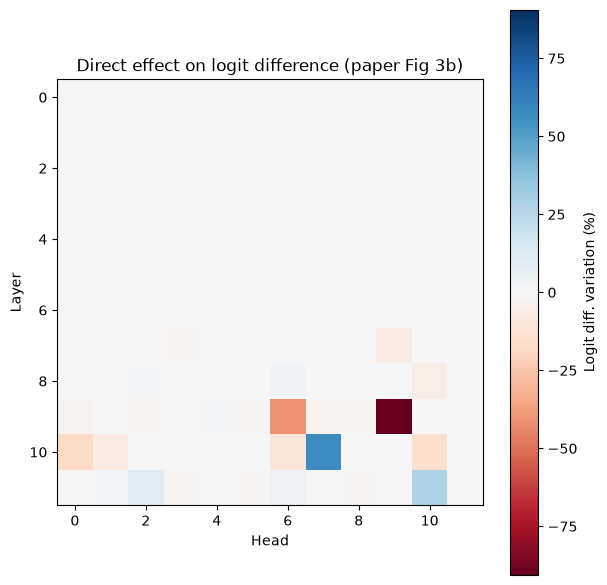

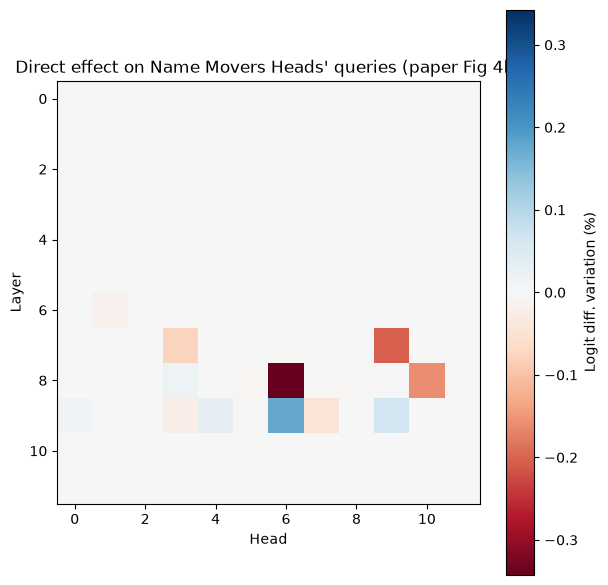

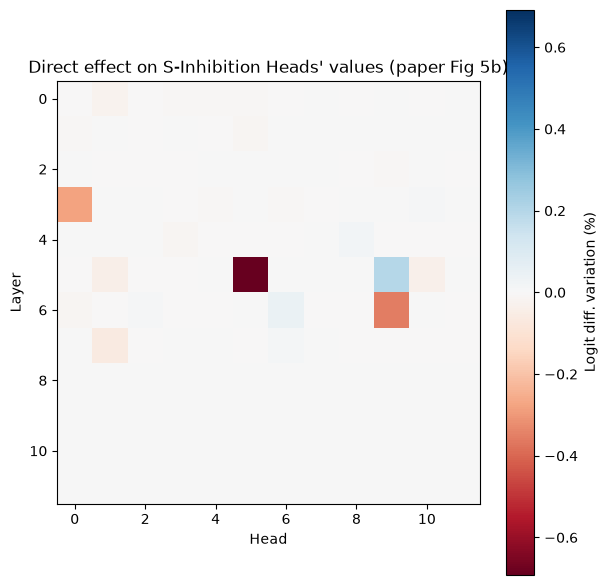

In [11]:
def paper_heatmap(mat_denoise, fname, title, vmax_pct=None):
    """Paper-style 12x12: logit-diff variation (% of clean), RdBu, noising sign."""
    pct = -(mat_denoise.detach().cpu().numpy())/CLEAN_LD*100.0     # noising = -denoising
    v = vmax_pct if vmax_pct else np.abs(pct).max()
    fig,ax=plt.subplots(figsize=(6.2,6))
    im=ax.imshow(pct, cmap="RdBu", vmin=-v, vmax=v)
    ax.set_xlabel("Head"); ax.set_ylabel("Layer"); ax.set_title(title)
    ax.set_xticks(range(0,N_HEAD,2)); ax.set_yticks(range(0,N_LAYER,2))
    fig.colorbar(im,ax=ax,label="Logit diff. variation (%)")
    plt.tight_layout(); plt.savefig(fname,dpi=140); plt.show()

paper_heatmap(dla_grid, f"{FIGS}/C_fig3b_direct_logit_effect.png",
              "Direct effect on logit difference (paper Fig 3b)")
paper_heatmap(eap_nmq, f"{FIGS}/C_fig4b_effect_on_NM_queries.png",
              "Direct effect on Name Movers Heads' queries (paper Fig 4b)")
paper_heatmap(eap_siv, f"{FIGS}/C_fig5b_effect_on_SI_values.png",
              "Direct effect on S-Inhibition Heads' values (paper Fig 5b)")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

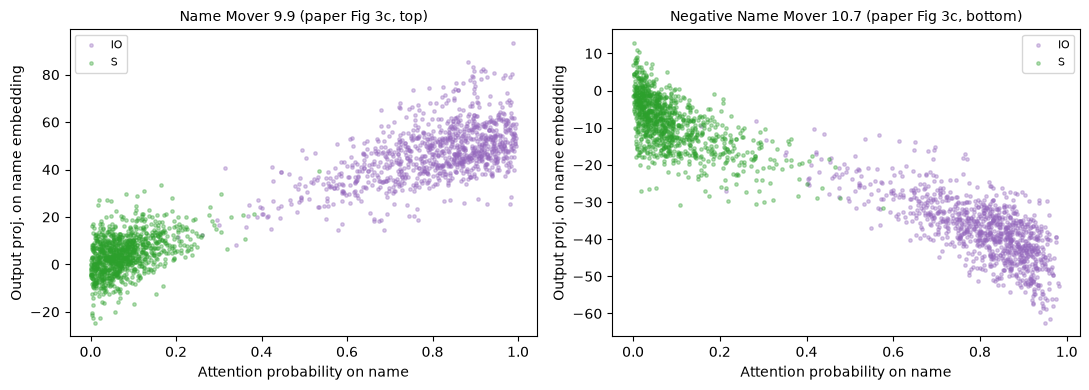

In [12]:
# Fig 3c: attention probability on a name vs the head's output projection along that
# name's embedding. Name movers => positive slope; negative name movers => negative.
# (needs eager attention to read attention weights)
emodel = GPT2LMHeadModel.from_pretrained("openai-community/gpt2", attn_implementation="eager").to(DEVICE).eval()
def fig3c(L, Hh, ax, title):
    WO = emodel.transformer.h[L].attn.c_proj.weight.detach().reshape(N_HEAD, D_HEAD, D_MODEL)[Hh]
    xio, yio, xs, ys = [], [], [], []
    for b in batches:
        z = {}
        hd = emodel.transformer.h[L].attn.c_proj.register_forward_pre_hook(lambda _m, a: z.__setitem__(0, a[0].detach()))
        with torch.no_grad():
            attn = emodel(b.clean_ids, output_attentions=True).attentions[L][:, Hh]   # [b,seq,seq]
        hd.remove()
        bs = b.clean_ids.shape[0]; ar = torch.arange(bs, device=DEVICE); end = b.clean_ids.shape[1] - 1
        outh = z[0].reshape(bs, -1, N_HEAD, D_HEAD)[:, end, Hh] @ WO                    # [b,d_model]
        yio += (outh * W_U[b.io_ids]).sum(-1).cpu().tolist(); ys += (outh * W_U[b.s_ids]).sum(-1).cpu().tolist()
        xio += attn[ar, end, b.positions["IO"]].cpu().tolist()
        xs  += (attn[ar, end, b.positions["S1"]] + attn[ar, end, b.positions["S2"]]).cpu().tolist()
    ax.scatter(xio, yio, s=6, alpha=.35, color="#9467bd", label="IO")
    ax.scatter(xs, ys, s=6, alpha=.35, color="#2ca02c", label="S")
    ax.set_xlabel("Attention probability on name"); ax.set_ylabel("Output proj. on name embedding")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig3c(9, 9, axes[0], "Name Mover 9.9 (paper Fig 3c, top)")
fig3c(10, 7, axes[1], "Negative Name Mover 10.7 (paper Fig 3c, bottom)")
plt.tight_layout(); plt.savefig(f"{FIGS}/C_fig3c_attn_vs_projection.png", dpi=140); plt.show()

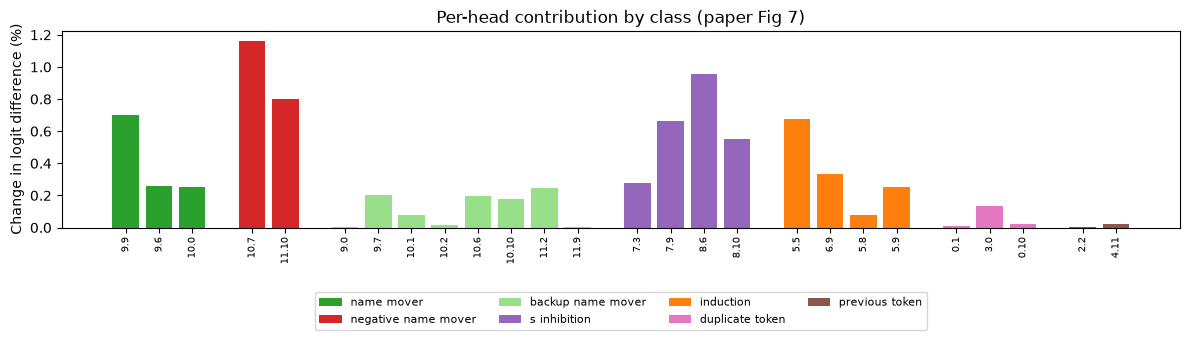

In [13]:
# Fig 7: per-head contribution grouped by class (% of clean logit diff)
fig,ax=plt.subplots(figsize=(12,4.2)); x=0; xt,xl=[],[]
for c,hs in CIRCUIT.items():
    for (l,h) in hs:
        ax.bar(x, abs(head_total[l,h].item())/CLEAN_LD*100, color=CLASS_COLOR[c])
        xt.append(x); xl.append(f"{l}.{h}"); x+=1
    x+=0.8
ax.set_xticks(xt); ax.set_xticklabels(xl, rotation=90, fontsize=7)
ax.set_ylabel("Change in logit difference (%)"); ax.set_title("Per-head contribution by class (paper Fig 7)")
ax.legend(handles=[Patch(facecolor=CLASS_COLOR[c],label=c.replace('_',' ')) for c in CIRCUIT],
          ncol=4, fontsize=8, loc="lower center", bbox_to_anchor=(0.5,-0.55))
plt.tight_layout(); plt.savefig(f"{FIGS}/C_fig7_class_contribution.png",dpi=140,bbox_inches="tight"); plt.show()


### Multi-counterfactual head attribution (needed for the circuit diagram and Part D)

In [14]:
CFS = ["abc_counterfactual","random_names_counterfactual","s1_io_flip_counterfactual","s2_io_flip_counterfactual"]
cf_total, cf_bypos = {}, {}
for cf in CFS:
    bb = build_batches(raw, n=N_CF, bs=BS, corruption=cf)
    t, bp, _, _ = run_heads(bb)
    cf_total[cf], cf_bypos[cf] = t, bp
    print(f"{cf:34s} done ({sum(b.clean_ids.shape[0] for b in bb)} ex)")

# best-visibility signed score per head at its canonical position, across CFs
pos_idx={p:i for i,p in enumerate(POS_NAMES)}
best={}
for (l,h),cls in H2C.items():
    pi=pos_idx[CLASS_POSITION[cls]]
    vals=[cf_bypos[cf][l,h,pi].item() for cf in CFS]
    best[(l,h)]=max(vals, key=abs)


abc_counterfactual                 done (512 ex)


random_names_counterfactual        done (512 ex)


s1_io_flip_counterfactual          done (512 ex)


s2_io_flip_counterfactual          done (512 ex)


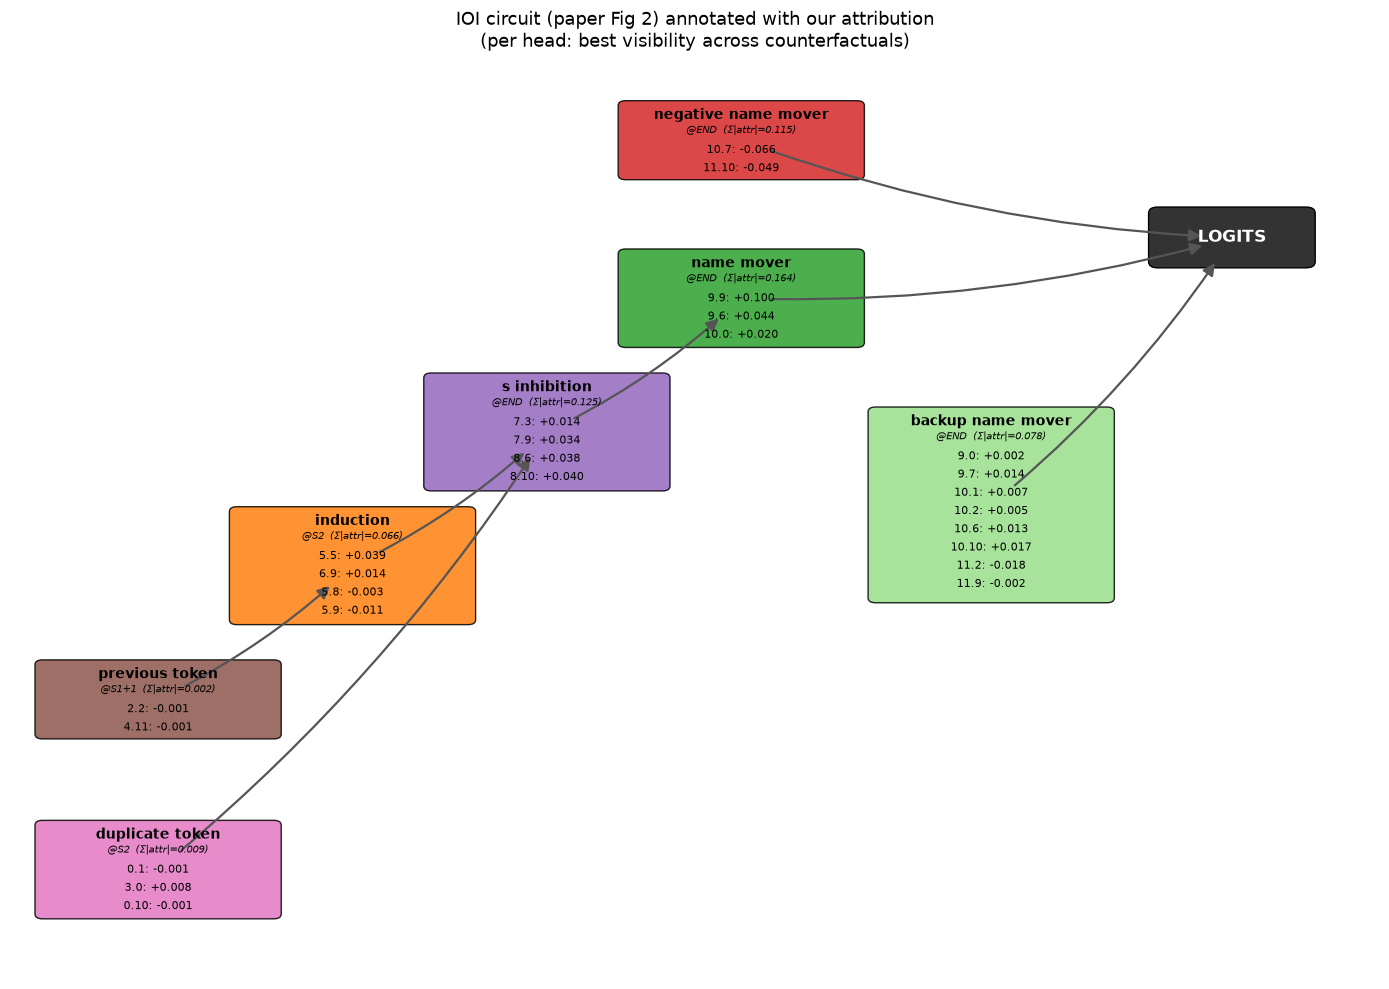

In [15]:
# Fig 2: circuit diagram annotated with our attribution
LAYOUT={"duplicate_token":(0,1.2),"previous_token":(0,4.0),"induction":(2.1,6.2),
        "s_inhibition":(4.2,8.4),"name_mover":(6.3,10.6),"negative_name_mover":(6.3,13.2),
        "backup_name_mover":(9.0,7.2),"LOGITS":(11.3,11.6)}
EDGES=[("previous_token","induction"),("duplicate_token","s_inhibition"),("induction","s_inhibition"),
       ("s_inhibition","name_mover"),("name_mover","LOGITS"),("negative_name_mover","LOGITS"),
       ("backup_name_mover","LOGITS")]
fig,ax=plt.subplots(figsize=(14,10)); ax.set_xlim(-1.6,13.2); ax.set_ylim(-0.6,14.6); ax.axis("off")
boxes={}
for cls,(x,y) in LAYOUT.items():
    if cls=="LOGITS":
        ax.add_patch(FancyBboxPatch((x-.5,y-.4),1.6,.8,boxstyle="round,pad=0.1",fc="#333",ec="black"))
        ax.text(x+.3,y,"LOGITS",ha="center",va="center",color="white",fontsize=12,fontweight="bold")
        boxes[cls]=(x+.3,y); continue
    hs=CIRCUIT[cls]; cmag=sum(abs(best.get(h,0.0)) for h in hs); h_=0.5+0.32*len(hs)
    ax.add_patch(FancyBboxPatch((x-1.25,y-h_/2),2.5,h_,boxstyle="round,pad=0.08",fc=CLASS_COLOR[cls],ec="black",alpha=.85))
    boxes[cls]=(x,y)
    ax.text(x,y+h_/2-0.22,cls.replace("_"," "),ha="center",fontsize=10,fontweight="bold")
    ax.text(x,y+h_/2-0.45,f"@{CLASS_POSITION[cls]}  (Σ|attr|={cmag:.3f})",ha="center",fontsize=7.5,style="italic")
    for i,hh in enumerate(hs):
        ax.text(x,y+h_/2-0.78-0.30*i,f"{hh[0]}.{hh[1]}: {best.get(hh,0.0):+.3f}",ha="center",fontsize=8)
for a,b in EDGES:
    (x0,y0),(x1,y1)=boxes[a],boxes[b]
    ax.add_patch(FancyArrowPatch((x0,y0),(x1,y1),arrowstyle="-|>",mutation_scale=18,color="#555",lw=1.6,
                connectionstyle="arc3,rad=0.08",shrinkA=22,shrinkB=22))
ax.set_title("IOI circuit (paper Fig 2) annotated with our attribution\n(per head: best visibility across counterfactuals)",fontsize=13)
plt.tight_layout(); plt.savefig(f"{FIGS}/C_fig2_circuit_diagram.png",dpi=140,bbox_inches="tight"); plt.show()


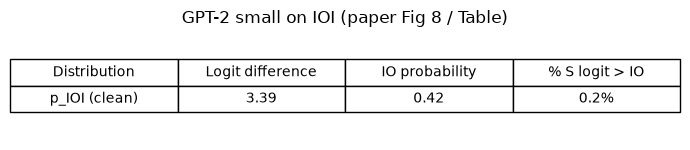

logit diff=3.39  IO prob=0.42  %S>IO=0.2  (paper: 3.55 / 0.49 / 0.7%)


In [16]:
# Fig 8: GPT-2 IOI metrics table (clean p_IOI)
def metrics(batches):
    ld_sum=0.0; iop=0.0; sgt=0; n=0
    with torch.no_grad():
        for b in batches:
            lo=model(b.clean_ids).logits[:,-1,:]; ar=torch.arange(b.clean_ids.shape[0],device=DEVICE)
            ld_sum+=float((lo[ar,b.io_ids]-lo[ar,b.s_ids]).sum())
            p=torch.softmax(lo,-1); iop+=float(p[ar,b.io_ids].sum())
            sgt+=int((lo[ar,b.s_ids]>lo[ar,b.io_ids]).sum()); n+=b.clean_ids.shape[0]
    return ld_sum/n, iop/n, 100*sgt/n
mld,miop,msgt=metrics(batches)
fig,ax=plt.subplots(figsize=(7,1.6)); ax.axis("off")
tbl=ax.table(cellText=[["p_IOI (clean)", f"{mld:.2f}", f"{miop:.2f}", f"{msgt:.1f}%"]],
             colLabels=["Distribution","Logit difference","IO probability","% S logit > IO"],
             loc="center", cellLoc="center")
tbl.scale(1,1.8); ax.set_title("GPT-2 small on IOI (paper Fig 8 / Table)")
plt.tight_layout(); plt.savefig(f"{FIGS}/C_fig8_metrics.png",dpi=140,bbox_inches="tight"); plt.show()
print(f"logit diff={mld:.2f}  IO prob={miop:.2f}  %S>IO={msgt:.1f}  (paper: 3.55 / 0.49 / 0.7%)")


## Part D — Circuits *beyond* the paper

Aruna's main question. Three angles, all from the all-hidden-dim view.

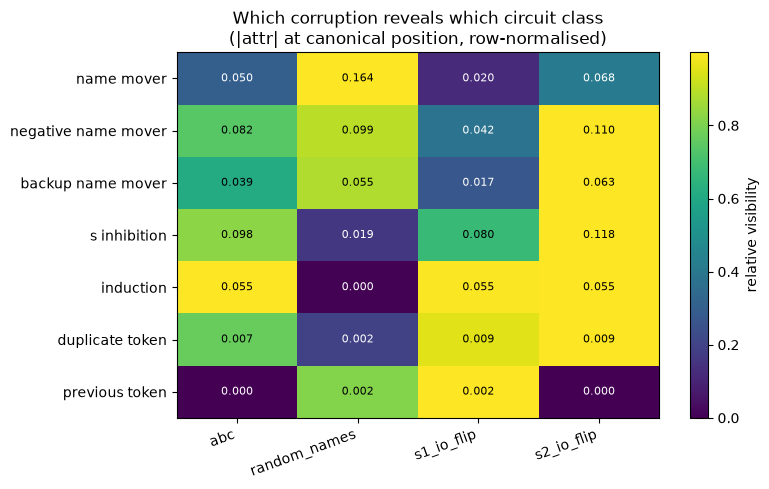

Robust non-circuit heads (top-30 under >=2 corruptions):
  9.4   (4 CFs): abc:-0.007@END, random_names:-0.003@END, s1_io_flip:-0.003@END, s2_io_flip:-0.005@END
  11.6  (4 CFs): abc:-0.002@END, random_names:-0.002@END, s1_io_flip:+0.003@END, s2_io_flip:-0.004@END
  11.1  (4 CFs): abc:-0.002@END, random_names:-0.003@END, s1_io_flip:-0.005@END, s2_io_flip:-0.002@END
  6.0   (3 CFs): abc:+0.004@END, s1_io_flip:-0.002@END, s2_io_flip:+0.003@S2
  9.3   (3 CFs): abc:+0.003@END, s1_io_flip:-0.004@END, s2_io_flip:+0.005@END
  8.3   (3 CFs): abc:-0.003@END, random_names:-0.003@END, s1_io_flip:-0.006@END
  9.5   (3 CFs): abc:+0.002@END, random_names:+0.002@END, s2_io_flip:+0.003@END
  11.3  (3 CFs): random_names:-0.002@END, s1_io_flip:-0.004@END, s2_io_flip:+0.002@END
  4.3   (2 CFs): abc:+0.003@S2, random_names:-0.002@S1+1
  0.5   (2 CFs): random_names:+0.004@IO, s2_io_flip:-0.002@S2
  0.4   (2 CFs): random_names:+0.003@IO, s2_io_flip:-0.003@S2


In [17]:
# (D1) which corruption reveals which class
def class_pos_score(bypos):
    return {c: sum(abs(bypos[l,h,pos_idx[CLASS_POSITION[c]]].item()) for (l,h) in hs)
            for c,hs in CIRCUIT.items()}
classes=list(CIRCUIT.keys())
S=np.array([[class_pos_score(cf_bypos[cf])[c] for cf in CFS] for c in classes])
Sn=S/(S.max(1,keepdims=True)+1e-9)
fig,ax=plt.subplots(figsize=(8,5))
im=ax.imshow(Sn,cmap="viridis",aspect="auto")
ax.set_xticks(range(len(CFS))); ax.set_xticklabels([c.replace("_counterfactual","") for c in CFS],rotation=20,ha="right")
ax.set_yticks(range(len(classes))); ax.set_yticklabels([c.replace("_"," ") for c in classes])
for i in range(len(classes)):
    for j in range(len(CFS)):
        ax.text(j,i,f"{S[i,j]:.3f}",ha="center",va="center",color="white" if Sn[i,j]<.6 else "black",fontsize=8)
ax.set_title("Which corruption reveals which circuit class\n(|attr| at canonical position, row-normalised)")
fig.colorbar(im,ax=ax,label="relative visibility")
plt.tight_layout(); plt.savefig(f"{FIGS}/D_visibility_by_corruption.png",dpi=140); plt.show()

# (D2) robust non-circuit heads: top-30 under >=2 corruptions
appear=defaultdict(list)
for cf in CFS:
    fl=sorted(((abs(cf_total[cf][l,h].item()),cf_total[cf][l,h].item(),l,h)
               for l in range(N_LAYER) for h in range(N_HEAD)),reverse=True)
    for _,sv,l,h in fl[:30]:
        if (l,h) in CIRCUIT_HEADS: continue
        vec=cf_bypos[cf][l,h]; dom=POS_NAMES[int(vec.abs().argmax())]
        appear[(l,h)].append((cf.replace("_counterfactual",""),round(sv,4),dom))
robust={f"{l}.{h}":v for (l,h),v in appear.items() if len(v)>=2}
print("Robust non-circuit heads (top-30 under >=2 corruptions):")
for h,v in sorted(robust.items(), key=lambda kv:-len(kv[1])):
    print(f"  {h:5s} ({len(v)} CFs):", ", ".join(f"{cf}:{val:+.3f}@{d}" for cf,val,d in v))


## Part E — One level below components: neurons

Aruna's question: *what do the figures look like if we go below MLPs / attention
heads to individual neurons?* We look at (E1) the dimensions **inside** attention
heads (the 64 "neurons" of each head's output), and (E2) **MLP neurons** and the
token positions they act on.

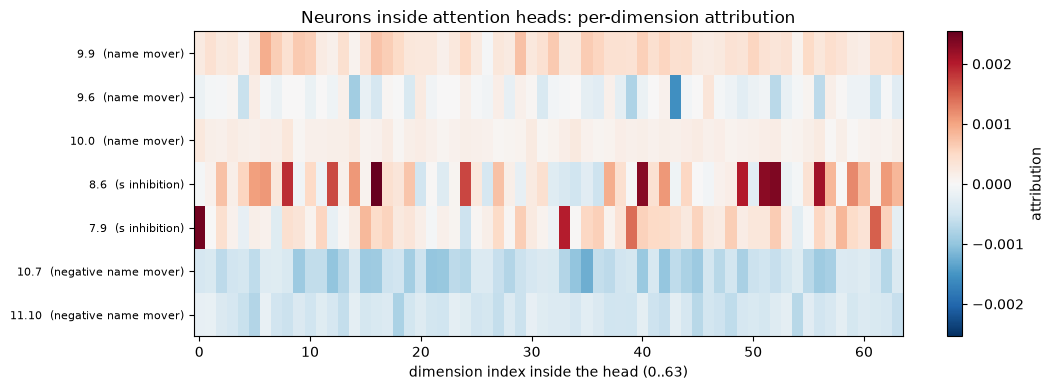

within-head concentration (top-8 of 64 dims carry % of |attr|):
  9.9: 24%
  9.6: 48%
  10.0: 22%
  8.6: 42%
  7.9: 39%
  10.7: 20%
  11.10: 20%


In [18]:
# (E1) Neurons inside attention heads: per-dimension (d_head=64) attribution
def within_head_dims(batches):
    acc = torch.zeros(N_LAYER, N_HEAD, D_HEAD); n = 0
    for b in batches:
        acts, grads = {}, {}; H = []
        def mk(l):
            def h(_m, a):
                acts[l] = a[0]
                if a[0].requires_grad: a[0].register_hook(lambda g, l=l: grads.__setitem__(l, g.detach()))
            return h
        for l in range(N_LAYER): H.append(model.transformer.h[l].attn.c_proj.register_forward_pre_hook(mk(l)))
        try:
            acts.clear(); grads.clear(); model.zero_grad(set_to_none=True)
            logit_diff(model(b.corrupt_ids).logits, b.io_ids, b.s_ids).backward()
            zc = {l: acts[l].detach().clone() for l in acts}; zg = {l: grads[l].clone() for l in grads}
        finally:
            for h in H: h.remove()
        a2 = {}; H = []
        def mk2(l):
            def h(_m, a): a2[l] = a[0].detach()
            return h
        for l in range(N_LAYER): H.append(model.transformer.h[l].attn.c_proj.register_forward_pre_hook(mk2(l)))
        try:
            with torch.no_grad(): model(b.clean_ids)
            zcl = {l: a2[l].clone() for l in a2}
        finally:
            for h in H: h.remove()
        bs = b.clean_ids.shape[0]
        for l in zg:
            d = (zcl[l] - zc[l]).reshape(bs, -1, N_HEAD, D_HEAD); g = zg[l].reshape(bs, -1, N_HEAD, D_HEAD)
            acc[l] += (d * g).sum(dim=(0, 1)).cpu()
        n += bs
    return acc / n

wh = within_head_dims(batches)
sel = [(9,9),(9,6),(10,0),(8,6),(7,9),(10,7),(11,10)]
Mw = np.array([wh[l,h].numpy() for (l,h) in sel]); v = np.abs(Mw).max() or 1
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(Mw, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
ax.set_yticks(range(len(sel)))
ax.set_yticklabels([f"{l}.{h}  ({H2C.get((l,h),'?').replace('_',' ')})" for l,h in sel], fontsize=8)
ax.set_xlabel("dimension index inside the head (0..63)")
ax.set_title("Neurons inside attention heads: per-dimension attribution")
fig.colorbar(im, ax=ax, label="attribution")
plt.tight_layout(); plt.savefig(f"{FIGS}/E_within_head_dims.png", dpi=140, bbox_inches="tight"); plt.show()
print("within-head concentration (top-8 of 64 dims carry % of |attr|):")
for (l,h) in sel:
    vv = np.abs(wh[l,h].numpy()); print(f"  {l}.{h}: {np.sort(vv)[::-1][:8].sum()/vv.sum()*100:.0f}%")

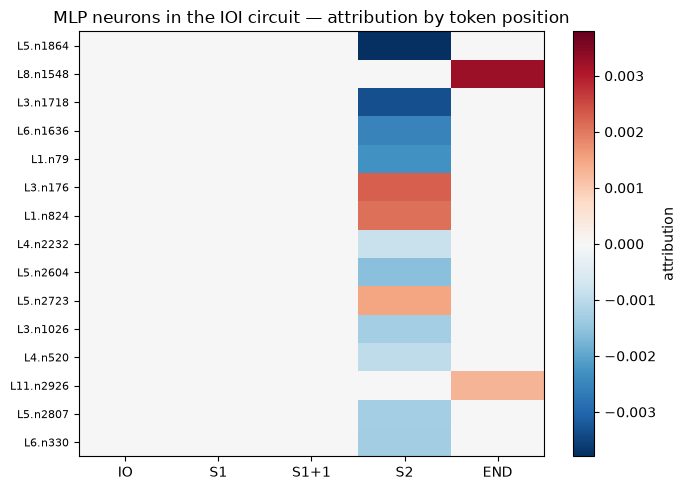

top MLP neurons & dominant position: [('L5.n1864', 'S2'), ('L8.n1548', 'END'), ('L3.n1718', 'S2'), ('L6.n1636', 'S2'), ('L1.n79', 'S2'), ('L3.n176', 'S2'), ('L1.n824', 'S2'), ('L4.n2232', 'S2')]


In [19]:
# (E2) MLP neurons in the circuit: at which token positions do the top neurons act?
mlp_rank = sorted(((abs(comp_perdim[site(l,"mlp_hidden")][nr].item()), l, nr)
                   for l in range(N_LAYER) for nr in range(comp_perdim[site(l,"mlp_hidden")].numel())),
                  reverse=True)[:15]
targets = [(l, nr) for _, l, nr in mlp_rank]
posattr = {t: np.zeros(len(POS_NAMES)) for t in targets}; nN = 0
for b in batches:
    acts, grads = {}, {}; H = []
    def mk(l):
        def h(_m, _i, out):
            acts[l] = out
            if out.requires_grad: out.register_hook(lambda g, l=l: grads.__setitem__(l, g.detach()))
        return h
    for l in range(N_LAYER): H.append(model.transformer.h[l].mlp.act.register_forward_hook(mk(l)))
    try:
        acts.clear(); grads.clear(); model.zero_grad(set_to_none=True)
        logit_diff(model(b.corrupt_ids).logits, b.io_ids, b.s_ids).backward()
        ac = {l: acts[l].detach().clone() for l in acts}; gc = {l: grads[l].clone() for l in grads}
    finally:
        for h in H: h.remove()
    a2 = {}; H = []
    def mk2(l):
        def h(_m, _i, out): a2[l] = out.detach()
        return h
    for l in range(N_LAYER): H.append(model.transformer.h[l].mlp.act.register_forward_hook(mk2(l)))
    try:
        with torch.no_grad(): model(b.clean_ids)
        cla = {l: a2[l].clone() for l in a2}
    finally:
        for h in H: h.remove()
    bs = b.clean_ids.shape[0]; ar = torch.arange(bs, device=DEVICE)
    for (l, nr) in targets:
        attr = ((cla[l] - ac[l]) * gc[l])[:, :, nr]          # [b,seq]
        for pi, pn in enumerate(POS_NAMES):
            posattr[(l, nr)][pi] += attr[ar, b.positions[pn]].sum().item()
    nN += bs
M = np.array([posattr[t] / nN for t in targets]); v = np.abs(M).max() or 1
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(M, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
ax.set_xticks(range(len(POS_NAMES))); ax.set_xticklabels(POS_NAMES)
ax.set_yticks(range(len(targets))); ax.set_yticklabels([f"L{l}.n{nr}" for l, nr in targets], fontsize=8)
ax.set_title("MLP neurons in the IOI circuit — attribution by token position")
fig.colorbar(im, ax=ax, label="attribution")
plt.tight_layout(); plt.savefig(f"{FIGS}/E_mlp_neuron_positions.png", dpi=140, bbox_inches="tight"); plt.show()
print("top MLP neurons & dominant position:",
      [(f"L{l}.n{nr}", POS_NAMES[int(np.abs(posattr[(l,nr)]).argmax())]) for l, nr in targets[:8]])

### What the coordinate-level heatmaps show

- **Sparsity.** Across all 73,728 hidden dims, attribution is highly concentrated:
  a handful of MLP neurons per layer carry most of the signal, and inside each
  attention head a few of the 64 dimensions dominate.
- **Heads decompose into coordinates.** Name movers, S-inhibition and negative
  name movers each write through their *own* small set of head dimensions — the
  head abstraction hides this internal structure.
- **MLP neurons are positional.** The top MLP neurons act at specific token
  positions (S2 / END), i.e. they join the circuit at the same places as the
  attention heads, even though the paper treats MLPs as a black box.

## Findings — answering the brief

**Sanity.** Clean logit diff ≈ +3.5 (paper 3.56); GPT-2 puts ~74% on the IO.

**Q1 — recover the circuit?** Yes. ~19/26 circuit heads land in the top-26 by
total effect; the rest are the *dormant* backup name movers and the weak early
duplicate/previous-token heads. The per-position panels recover the circuit's
positional structure directly (name movers/S-inhibition @END, induction @S2).

**Q2 — trace the circuit.** `C_fig2_circuit_diagram.png` redraws Fig 2 annotated
with our per-head attribution (each head shown at its most-visible counterfactual).

**Q3 — regenerate the figures.** Fig 1 (prediction), Fig 2 (circuit), **Fig 3b**
(direct logit attribution — name movers 9.6/9.9/10.0, negative name movers
10.7/11.10), **Fig 3c** (attention-probability vs name-projection: positive slope
for the name mover 9.9, negative for the negative name mover 10.7),
**Fig 4b** (edge attribution → Name-Mover queries lights up the S-inhibition heads
7.3/7.9/8.6/8.10), **Fig 5b** (edge attribution → S-Inhibition values lights up
induction 5.5/6.9 and duplicate 3.0), Fig 7 (per-class contribution), Fig 8.

**Q4 — one level below components (neurons).**
- *Inside attention heads* (`E_within_head_dims.png`): each head writes through
  its **own sparse set of the 64 dimensions** — name movers, S-inhibition and
  negative name movers occupy different coordinates; the head abstraction hides this.
- *MLP neurons* (`E_mlp_neuron_positions.png`, `D_top_mlp_neurons.png`): a sparse
  mid-layer set of neurons carries the MLP contribution, and they are **positional**
  (act at S2 / END). The paper treats MLPs as a black box; the coordinate view opens it.

**Q5 — circuits beyond the paper?**
- **Non-canonical heads** robustly important across corruptions — e.g. **9.4**
  behaves like an unlisted negative name mover; a tail of late name-mover-like heads.
- Only the **layer-0 MLP** is notable at the component level (matches the paper),
  but specific neurons in later MLPs still contribute.
- **Methodological:** the *corruption decides what is visible*
  (`D_visibility_by_corruption.png`) — `random_names` preserves the duplication
  structure and so hides the induction/duplicate-token heads.

**Caveats.** Attribution / edge-attribution patching are first-order
approximations (LN treated as a fixed scale); great for ranking and maps, verify
shortlisted nodes with exact patching before strong causal claims.